배터리 이미지 EDA

In [2]:
import os

print(os.getcwd())

d:\02.study\part4_wj\Battery\Battery_Project\notebooks


### 이미지↔JSON 매칭 전수 검사

In [3]:
import glob

lbl_dir = '../battery_label'
img_dir = '../battery_image'

img_set = {os.path.splitext(os.path.basename(p))[0]
           for p in glob.glob(os.path.join(img_dir, '*.png'))}
lbl_set = {os.path.splitext(os.path.basename(p))[0]
           for p in glob.glob(os.path.join(lbl_dir, '*.json'))}

orphans_img = sorted(img_set - lbl_set)   # 라벨 없는 이미지
orphans_lbl = sorted(lbl_set - img_set)   # 이미지 없는 라벨

audit_pairing = {
    'image_files': len(img_set),
    'label_files': len(lbl_set),
    'paired': len(img_set & lbl_set),
    'orphan_images': len(orphans_img),
    'orphan_labels': len(orphans_lbl),
}
print(audit_pairing)

{'image_files': 249, 'label_files': 249, 'paired': 249, 'orphan_images': 0, 'orphan_labels': 0}


In [4]:
import json

all_data = []

for file_name in glob.glob('../battery_label/*.json'):
    with open(file_name, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_data.append(data)

### 해상도 일치 검사 (JSON image_info.width/height vs 실제 이미지)

In [5]:
import cv2
mismatches = []
for data in all_data:
    info = data.get('image_info', {})
    fn = info.get('file_name')
    expected = (info.get('width'), info.get('height'))
    img = cv2.imread(os.path.join(img_dir, fn))
    if img is None:
        mismatches.append((fn, 'IMAGE_NOT_FOUND', expected))
        continue
    actual = (img.shape[1], img.shape[0])
    if expected != actual:
        mismatches.append((fn, expected, actual))
print(f'해상도 불일치: {len(mismatches)} / {len(all_data)} 건')

해상도 불일치: 0 / 249 건


전처리 파이프라인은 JSON `image_info`를 신뢰하여 리사이즈/패딩을 결정합니다.

본 검사로 해당 가정이 학습 전체 데이터셋에서 성립함을 보증합니다.

In [6]:
# 좌표 구조 시각적 검증
sample_data = all_data[54]
print("1. 전체 키 목록: ")
print(sample_data.keys())
print('-'*70)

1. 전체 키 목록: 
dict_keys(['data_info', 'swelling', 'defects', 'image_info'])
----------------------------------------------------------------------


In [7]:
if 'defects' in sample_data and sample_data['defects']:
    first_defect = sample_data['defects'][0]
    print("2. 결함 정보 상세: ")
    print(f"    - 종류(name): {first_defect.get('name')}")
    
    points = first_defect.get('points', [])
    print(f"    - points 데이터 길이 : {len(points)}개")
    print(f"    - points 데이터 앞 부분 추출 : {points[:4]}")
    print('-'*70)

2. 결함 정보 상세: 
    - 종류(name): Pollution
    - points 데이터 길이 : 62개
    - points 데이터 앞 부분 추출 : [949.0, 63.0, 984.0, 65.0]
----------------------------------------------------------------------


**데이터 형태 관찰 및 가설**

`points` 리스트의 길이사 짝수이며, 연속된 수치형 데이터로 구성 되어있습니다.

결함 영역을 나타내는 데이터의 특성상, `[x1, y1, x2, y2, ..]` 와 같이 x,y 좌표 쌍이 1차원 배열로 펼쳐져 나열된 형태일 가능성이 높다고 판단합니다.

이 가설을 검증하기 위해, 다음 단계에서 실제 원본 배터리의 이미지 위에 이 좌표들을 폴리곤(Polygon) 형태로 시각화하여 결함 위치와 일치하는지 교차 검증 하겠습니다.

## 폴리곤 유효성 검사 (좌표쌍 짝수, 점 ≥3, 좌표 음수/범위 초과 없음)

In [8]:
invalid = []
for data in all_data:
    fn = data.get('image_info', {}).get('file_name')
    W, H = data['image_info']['width'], data['image_info']['height']
    for d in data.get('defects', []) or []:
        pts = d.get('points', [])
        if len(pts) % 2 != 0 or len(pts) < 6:
            invalid.append((fn, d.get('name'), 'BAD_POINTS_LEN', len(pts)))
            continue
        xs, ys = pts[0::2], pts[1::2]
        if any(x < 0 or x > W for x in xs) or any(y < 0 or y > H for y in ys):
            invalid.append((fn, d.get('name'), 'OUT_OF_BOUNDS', None))
print(f'잘못된 폴리곤: {len(invalid)} 건')

잘못된 폴리곤: 0 건


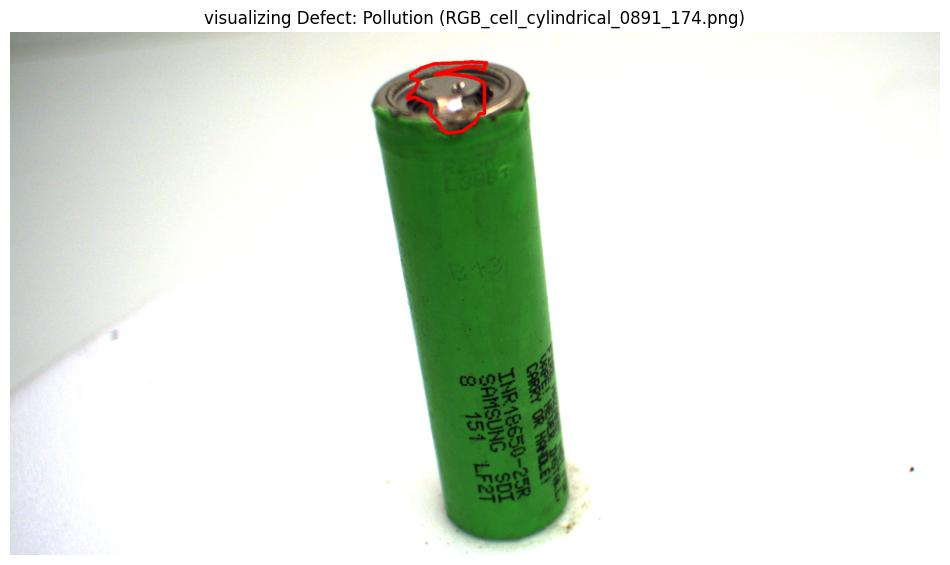

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 이미지 경로 설정
image_dir = "../battery_image"
image_filename = sample_data.get('image_info', {}).get('file_name')
image_path = os.path.join(image_dir, image_filename)

# 2. 1차원 points 리스트를 (x,y) 쌍의 2차원 numpy 배열로 변환
# [x1, y1, x2, y2,..] -> [[x1, y1], [x2, y2], ...]
if len(points) >=4:
    # 정수형으로 변환 후 2열 구조로 재배열 (cv2.polylines 포멧)
    polygon_points = np.array(points, dtype=np.int32).reshape((-1, 2))
else:
    polygon_points = None

# 3. 이미지 로드 및 시각화
if os.path.exists(image_path) and polygon_points is not None:
    # 이미지 읽기
    img = cv2.imread(image_path)
    # OpenCV(BGR) -> Matplotlib(RGB) 변환
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # 이미지 위에 결함 영역(Polygon) 그리기
    cv2.polylines(img_rgb, [polygon_points], isClosed=True, color=(255,0,0), thickness=5)
    
    # 시각화
    plt.figure(figsize=(12,8))
    plt.imshow(img_rgb)
    plt.title(f"visualizing Defect: {first_defect.get('name')} ({image_filename})")
    plt.axis('off')
    plt.show()

In [10]:
from collections import Counter
defect_name = []

for data in all_data:
    # 1. data가 있는지
    # 2. 'defects' 가 있는지
    # 3. 그 값이 리스트인 경우 진행
    defects = data.get('defects')
    if isinstance(defects, list):
        for defect in defects:
            name = defect.get('name')
            if name:
                defect_name.append(name)
                
defect_counts = Counter(defect_name)
print(defect_counts)

Counter({'Pollution': 912, 'Damaged': 227})


In [11]:
total = sum(defect_counts.values())
for name, count in defect_counts.items():
    percentage = (count/total) * 100
    print(f"{name}: {count}개 ({percentage:.2f}%)")

Pollution: 912개 (80.07%)
Damaged: 227개 (19.93%)


전체 결함 중 `Pollution` 이 80%를 차지하고 `Damaged` 는 약 20% 정도 입니다.

데이터 불균형으로 인해 `Pollution` 만 잘 찾을 수 있고 `Damaged` 는 놓칠 가능성이 있습니다.

In [12]:
# 결함 이미지 확인

import cv2
import matplotlib.pyplot as plt
import random
random.seed(42)

# 이미지 폴더 경로 설정
IMAGE_DIR = '../battery_image'

def visualize_samples(all_data, target_defect, num_samples=3):
    # 1. 특정 경함이 포함된 데이터만 필터링
    samples = []
    for data in all_data:
        defects = data.get('defects')
        if defects and any(d.get('name') == target_defect for d in defects):
            samples.append(data)
            
    # 2. 무작위 진행
    if len(samples) > num_samples:
        selected_samples = random.sample(samples, num_samples)
    else:
        selected_samples = samples

    # 3. 시각화 설정
    plt.figure(figsize=(15,5))
    plt.suptitle(f"Defect Type: {target_defect}", fontsize=16)
    
    for i , data in enumerate(selected_samples):
        # JSON 정보에서 이미지 파일명 가져오기 (image_info 또는 파일명 매칭)
        img_name = data['image_info']['file_name']
        img_path = os.path.join(IMAGE_DIR, img_name)
        
        # 이미지 읽기
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 결함 위치 표시
        for defect in data.get('defects', []):
            if defect.get('name') == target_defect:
                points = defect.get('points', [])
                if len(points) >= 4: # 최소 2쌍 이상의 좌표 필요
                    poly_pts = np.array(points, dtype=np.int32).reshape((-1,2))
                    cv2.polylines(img, [poly_pts], isClosed=True, color=(255,0,0), thickness=8)
                    cv2.putText(img, target_defect, (poly_pts[0][0], poly_pts[0][1]-20),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,0,0), 4)
                   
        # 출력
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"File: {img_name}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

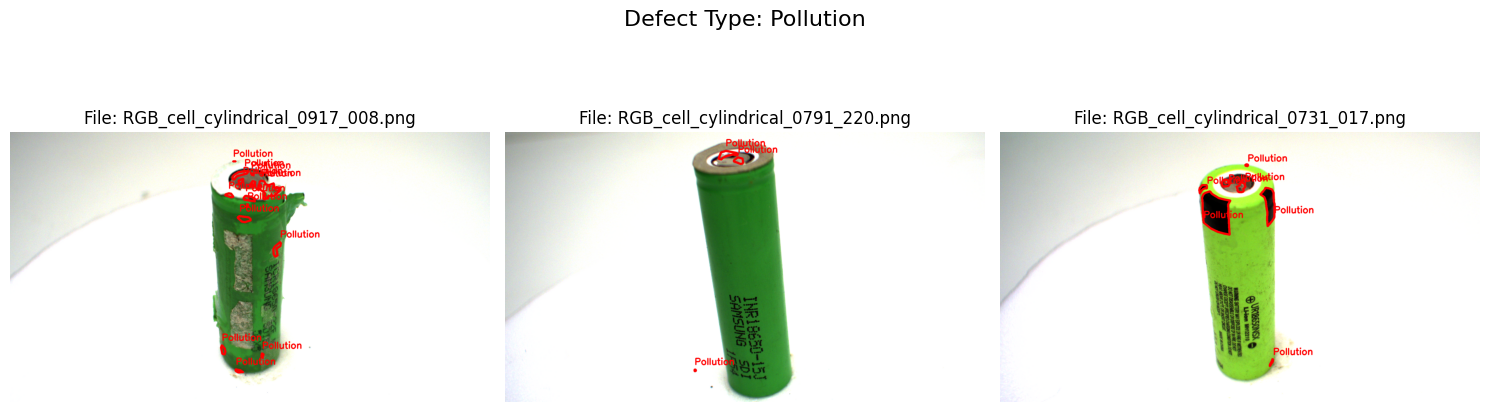

In [13]:
visualize_samples(all_data, 'Pollution', num_samples=3)

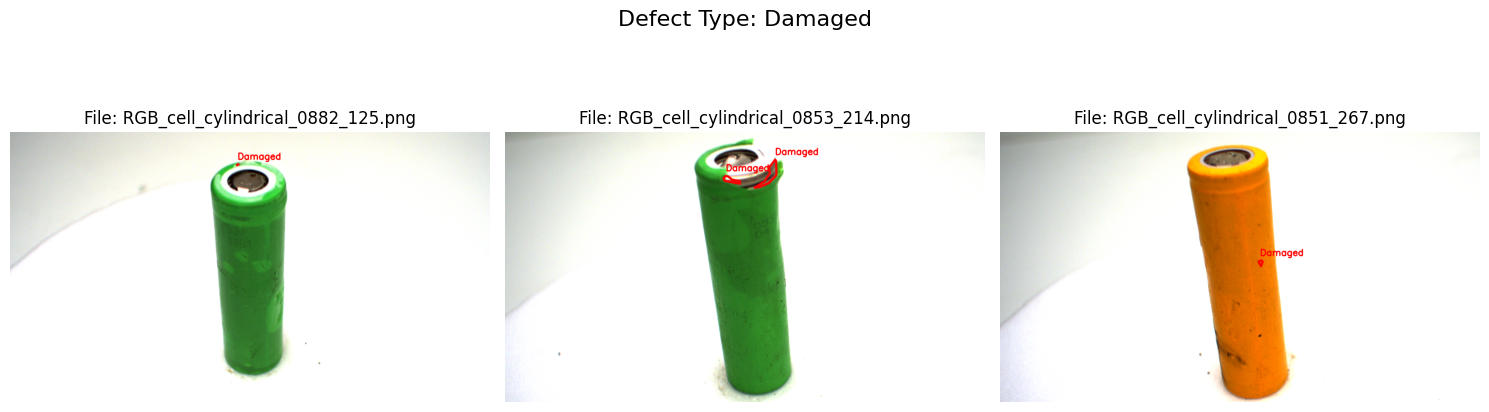

In [14]:
visualize_samples(all_data, 'Damaged', num_samples=3)

## 결함 무게중심 히트맵 (이미지 좌표 정규화)

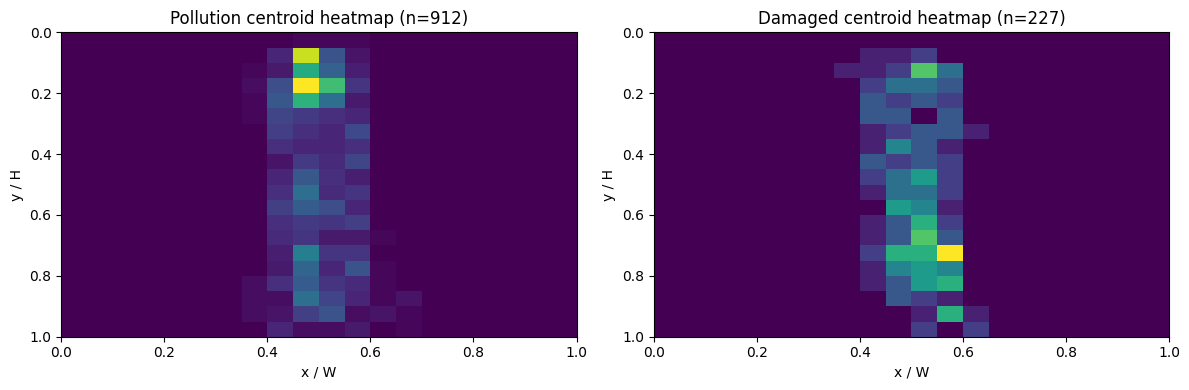

In [15]:
import numpy as np, matplotlib.pyplot as plt

centers = {'Pollution': [], 'Damaged': []}
for data in all_data:
    W = data['image_info']['width']
    H = data['image_info']['height']
    for d in data.get('defects', []) or []:
        name = d.get('name')
        pts = np.array(d.get('points', [])).reshape(-1, 2).astype(np.float32)
        if len(pts) < 3 or name not in centers:
            continue
        cx, cy = pts[:, 0].mean() / W, pts[:, 1].mean() / H
        centers[name].append((cx, cy))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pts) in zip(axes, centers.items()):
    arr = np.array(pts)
    ax.hist2d(arr[:, 0], arr[:, 1], bins=20, range=[[0, 1], [0, 1]])
    ax.invert_yaxis()              # 이미지 좌표계
    ax.set_title(f'{name} centroid heatmap (n={len(pts)})')
    ax.set_xlabel('x / W'); ax.set_ylabel('y / H')
plt.tight_layout(); plt.show()

> Pollution
Damaged는 하단 ROI 편중 → 룰베이스에서 하단 영역 가중치 검토

> "Pollution은 셀 상단/하단 양 끝단에 집중되는 경향. Damaged는 분포가 분산되어 ROI 가중치 적용은 보류하고 전체 영역 학습으로 결정. 단, 향후 라인별 데이터 확보 시 라인 ID를 라벨에 추가하여 ROI별 정확도를 분리 모니터링"

**스웰링(Swelling) 유무 확인**

> 배터리 결함 중 하나인 '스웰링' 현상은 내부 가스 발생으로 인해 외형이 변형되는 심각한 불량입니다. 해당 데이터셋에서는 모든 이미지에 대해 스웰링 여부를 True/False로 제공하고 있으며, 대부분의 데이터가 False인 불균형 데이터인지 혹은 학습에 충분한 불량 사례가 있는지 확인이 필요합니다.

In [54]:
# swelling.swelling 분포
swelling_flags = []
for data in all_data:
    sw = data.get('swelling', {})
    swelling_flags.append(sw.get('swelling'))

from collections import Counter
print(Counter(swelling_flags))

Counter({False: 249})


**데이터셋 정상/불량 비율 확인**
>`is_normal` 플래그는 해당 이미지에 결함이 하나라도 존재하는지 여부를 나타내는 최상위 라벨입니다. 이는 모델이 '정상/불량'을 분류(Classification)하는 기준이 되며, 현재 데이터셋에서 정상 이미지와 결함 이미지가 어떤 비율로 구성되어 있는지 파악하여 학습 전략(데이터 증강 등)을 수립합니다

Counter({True: 160, False: 89})


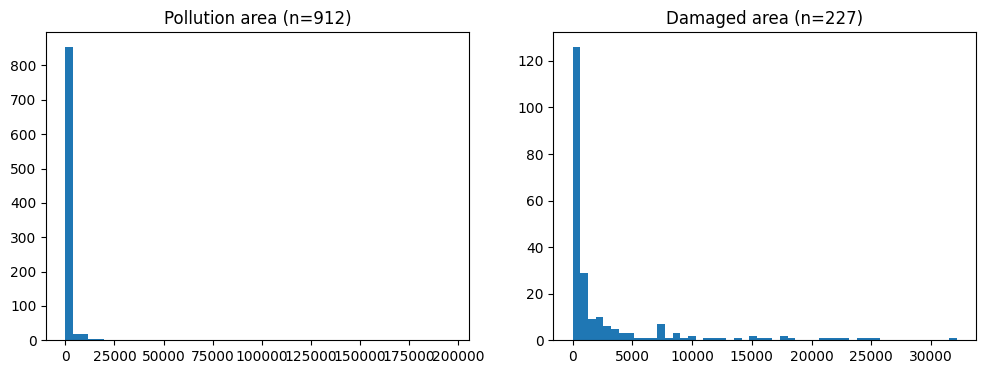

In [55]:
# image_info.is_normal 분포
normal_flags = [d.get('image_info', {}).get('is_normal') for d in all_data]
print(Counter(normal_flags))
# 정상 vs 비정상 비율

# 결함 면적 분포 (클래스별로 분리)
import numpy as np

areas_by_class = {'Pollution': [], 'Damaged': []}
for data in all_data:
    for defect in data.get('defects', []) or []:
        name = defect.get('name')
        pts = np.array(defect.get('points', [])).reshape(-1, 2).astype(np.float32)
        if len(pts) >= 3 and name in areas_by_class:
            # Shoelace formula 또는 cv2.contourArea
            area = 0.5 * abs(np.dot(pts[:,0], np.roll(pts[:,1], -1))
                            - np.dot(pts[:,1], np.roll(pts[:,0], -1)))
            areas_by_class[name].append(area)

# 히스토그램 비교
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(areas_by_class['Pollution'], bins=50)
ax[0].set_title(f'Pollution area (n={len(areas_by_class["Pollution"])})')
ax[1].hist(areas_by_class['Damaged'], bins=50)
ax[1].set_title(f'Damaged area (n={len(areas_by_class["Damaged"])})')
plt.show()

**결함 복잡도 분석 (이미지당 결함 수)**
> 하나의 배터리 이미지에 여러 개의 결함이 동시에 존재할 수 있습니다. Pollution과 Damaged 각각의 이미지당 발생 개수를 분석함으로써, 결함이 밀집되어 나타나는 경향이 있는지 확인합니다. 만약 특정 이미지에 결함이 너무 많이 몰려 있다면, 이는 탐지 모델(Detection)의 난이도를 높이는 요인이 될 수 있습니다.

        Pollution     Damaged
count  249.000000  249.000000
mean     3.662651    0.911647
std      6.121638    2.454469
min      0.000000    0.000000
25%      0.000000    0.000000
50%      0.000000    0.000000
75%      6.000000    0.000000
max     25.000000   15.000000


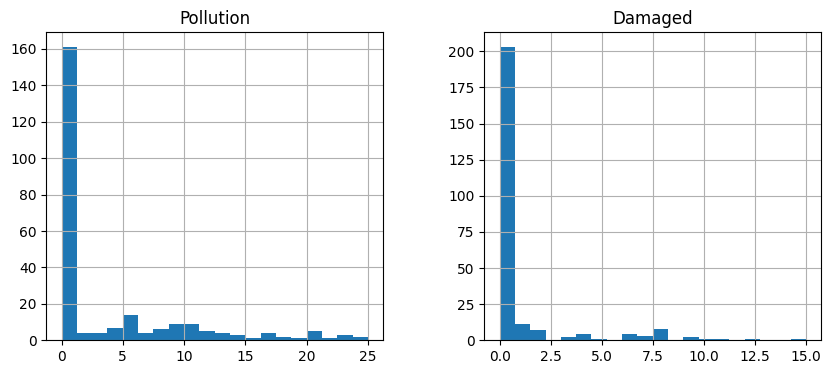

In [51]:
# 이미지당 결함 개수 분포 (Pollution/Damaged 별)
defect_counts_per_image = {'Pollution': [], 'Damaged': []}
for data in all_data:
    cnt = Counter(d.get('name') for d in data.get('defects', []) or [])
    defect_counts_per_image['Pollution'].append(cnt.get('Pollution', 0))
    defect_counts_per_image['Damaged'].append(cnt.get('Damaged', 0))
# 평균/중앙값/최대 → 표로 출력
import pandas as pd
df_cnt = pd.DataFrame(defect_counts_per_image)
print(df_cnt.describe())  # 평균/min/max/quartile
df_cnt.hist(bins=20, figsize=(10,4)); plt.show()

In [52]:
summary = {
      'total_images': len(all_data),
      'total_defects': total,
      'pollution_count': defect_counts['Pollution'],
      'damaged_count': defect_counts['Damaged'],
      'pollution_ratio': 0.8007,
      'damaged_ratio': 0.1993,
      'swelling_true': Counter(swelling_flags).get(True, 0),
      'is_normal_true': Counter(normal_flags).get(True, 0),
      'pollution_area_median': np.median(areas_by_class['Pollution']),
      'damaged_area_median': np.median(areas_by_class['Damaged']),
  }

pd.DataFrame([summary]).to_csv('eda_summary.csv', index=False)

### 핵심 발견
  - 데이터 무결성 100%
  - 클래스 불균형 80:20 → Damaged 재현율 위험
  - Damaged 하단 편중 → 룰베이스 ROI 근거
  - swelling/is_normal 단일값 → 검출 과제로 한정

### 다음 단계 (D2) — 액션 4개로 명시
  1. JSON 폴리곤 → 마스크 PNG 변환
  2. train/val/test 분할 (클래스 비율 유지)
  3. 증강: 좌우 flip OK, 상하 flip 금지 (공간 편중 보존)
  4. Matrox 룰베이스: Damaged 하단 ROI 가중치 프로토타입